<a href="https://www.kaggle.com/code/rakesh00966/zomato-dataset-cleaning?scriptVersionId=257250363" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# **Zomato Restaurants Dataset Analysing**
<hr style="border:1px solid gray">

This notebook performs an exploratory data analysis (EDA) on the Zomato Bangalore Restaurants dataset.

**Aim**: To understand how restaurants development being caused due to their features and finding the new place that is suitable for building new restaurants based on the data.
* In this Project I'm gonna do
* Dataset loading and preprocessing
* Data cleaning and basic transformations

<hr style="border:1px solid gray">

# MetaData
<hr style="border:1px solid gray">

* url => Restaurant website.

* address => Full street address of the restaurant.

* name => Name of the restaurant.

* online_order => Indicates whether the restaurant accepts online orders. Values are "Yes" or "No".

* book_table => Shows whether the restaurant provides table booking facilities. Values are "Yes" or "No".

* rate => Average user rating for the restaurant (e.g., "4.2/5"). May contain strings like "NEW" or "–" which should be cleaned. After cleaning, this should be numeric.

* votes => Number of user votes the restaurant has received. Indicates popularity.

* phone => Phone number of the restaurant. Often inconsistently formatted or missing.

* location => The neighborhood or area in Bangalore where the restaurant is located.

* rest_type => The type or format of the restaurant (e.g., Casual Dining, Cafe, Quick Bites, Delivery, etc.).

* dish_liked => Text field containing a list of dishes liked by customers, based on user reviews.

* cuisines => Comma-separated list of cuisines offered by the restaurant (e.g., North Indian, Chinese, Fast Food, etc.).

* approx_cost(for two people) => Approximate cost for two people. Comes as a string with commas (e.g., "1,200") and needs to be cleaned to numeric.

* reviews_list => Raw, nested text field containing multiple user reviews and associated metadata. Very unstructured and rarely used without heavy parsing.

* menu_item => Raw text or semi-structured JSON-like string representing some of the menu items.

* listed_in(type) => Category under which the restaurant is listed on Zomato (e.g., Buffet, Cafes, Delivery, Pubs, etc.).

* listed_in(city) => Sub-region or part of Bangalore for further zoning (e.g., BTM, JP Nagar, Whitefield).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/kaggle/input/zomato-bangalore-restaurants/zomato.csv')
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [3]:
df.shape

(51717, 17)

#  Removing unnecessary coloumns
* Some coloumns are unnecessary for doing analysis

In [4]:
df.shape

(51717, 17)

In [5]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [6]:
df = df.drop(['url','address','dish_liked','menu_item','phone','reviews_list'], axis = 1)

In [7]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         51717 non-null  object
 1   online_order                 51717 non-null  object
 2   book_table                   51717 non-null  object
 3   rate                         43942 non-null  object
 4   votes                        51717 non-null  int64 
 5   location                     51696 non-null  object
 6   rest_type                    51490 non-null  object
 7   cuisines                     51672 non-null  object
 8   approx_cost(for two people)  51371 non-null  object
 9   listed_in(type)              51717 non-null  object
 10  listed_in(city)              51717 non-null  object
dtypes: int64(1), object(10)
memory usage: 4.3+ MB


# Renaming the Coloumns
* The coloumn names are renamed for better understanding of the data

In [9]:
df.rename(columns = {'approx_cost(for two people)':'2platescost', 'listed_in(type)':'Type'}, inplace = True)
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,2platescost,Type,listed_in(city)
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari


# Dropping Duplicate rows

In [10]:
df.drop_duplicates(inplace =True)
df.shape

(51609, 11)

# Cleaning coloumns wise

# 1. Rate coulumn

In [11]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

* **Removing 'NEW','-' which are not numerical values**
* **Making sure all the values are numerical**
* **Also removing /5 from the values for better understanding of values and making it suitable for calculating the average**

In [12]:
def handle_rate(value):
    if value in ['NEW','-']:
        return np.nan
    else:
        value = str(value).split('/')
        value = value[0]
        return float(value)

df['rate'] = df['rate'].apply(handle_rate)
df['rate'].head()

0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: float64

In [13]:
df['rate'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, nan, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2,
       2.3, 4.8, 4.9, 2.1, 2. , 1.8])

* **Filling the null values in rate coloumn with the average value**

In [14]:
df['rate'] = df['rate'].fillna(df['rate'].mean())
df['rate'].head()

0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: float64

**Checking for the Null values**

In [15]:
df['rate'].isnull().sum()
#rate coloumn is cleaned

0

In [16]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'cuisines', '2platescost', 'Type', 'listed_in(city)'],
      dtype='object')

# 2. location,listed_in(city) coloumns

In [17]:
df['location'].unique()

array(['Banashankari', 'Basavanagudi', 'Mysore Road', 'Jayanagar',
       'Kumaraswamy Layout', 'Rajarajeshwari Nagar', 'Vijay Nagar',
       'Uttarahalli', 'JP Nagar', 'South Bangalore', 'City Market',
       'Nagarbhavi', 'Bannerghatta Road', 'BTM', 'Kanakapura Road',
       'Bommanahalli', nan, 'CV Raman Nagar', 'Electronic City', 'HSR',
       'Marathahalli', 'Sarjapur Road', 'Wilson Garden', 'Shanti Nagar',
       'Koramangala 5th Block', 'Koramangala 8th Block', 'Richmond Road',
       'Koramangala 7th Block', 'Jalahalli', 'Koramangala 4th Block',
       'Bellandur', 'Whitefield', 'East Bangalore', 'Old Airport Road',
       'Indiranagar', 'Koramangala 1st Block', 'Frazer Town', 'RT Nagar',
       'MG Road', 'Brigade Road', 'Lavelle Road', 'Church Street',
       'Ulsoor', 'Residency Road', 'Shivajinagar', 'Infantry Road',
       'St. Marks Road', 'Cunningham Road', 'Race Course Road',
       'Commercial Street', 'Vasanth Nagar', 'HBR Layout', 'Domlur',
       'Ejipura', 'Jeevan 

In [18]:
df['listed_in(city)'].unique()

array(['Banashankari', 'Bannerghatta Road', 'Basavanagudi', 'Bellandur',
       'Brigade Road', 'Brookefield', 'BTM', 'Church Street',
       'Electronic City', 'Frazer Town', 'HSR', 'Indiranagar',
       'Jayanagar', 'JP Nagar', 'Kalyan Nagar', 'Kammanahalli',
       'Koramangala 4th Block', 'Koramangala 5th Block',
       'Koramangala 6th Block', 'Koramangala 7th Block', 'Lavelle Road',
       'Malleshwaram', 'Marathahalli', 'MG Road', 'New BEL Road',
       'Old Airport Road', 'Rajajinagar', 'Residency Road',
       'Sarjapur Road', 'Whitefield'], dtype=object)

* **Both coloumns describing about locations**
* **Since the coloumn listed_in(city) having less unique values, drop it**

In [19]:
df = df.drop('listed_in(city)',axis = 1)
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,2platescost,Type
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet


# 3. Modifying location coloumn

In [20]:
df["location"].unique()

array(['Banashankari', 'Basavanagudi', 'Mysore Road', 'Jayanagar',
       'Kumaraswamy Layout', 'Rajarajeshwari Nagar', 'Vijay Nagar',
       'Uttarahalli', 'JP Nagar', 'South Bangalore', 'City Market',
       'Nagarbhavi', 'Bannerghatta Road', 'BTM', 'Kanakapura Road',
       'Bommanahalli', nan, 'CV Raman Nagar', 'Electronic City', 'HSR',
       'Marathahalli', 'Sarjapur Road', 'Wilson Garden', 'Shanti Nagar',
       'Koramangala 5th Block', 'Koramangala 8th Block', 'Richmond Road',
       'Koramangala 7th Block', 'Jalahalli', 'Koramangala 4th Block',
       'Bellandur', 'Whitefield', 'East Bangalore', 'Old Airport Road',
       'Indiranagar', 'Koramangala 1st Block', 'Frazer Town', 'RT Nagar',
       'MG Road', 'Brigade Road', 'Lavelle Road', 'Church Street',
       'Ulsoor', 'Residency Road', 'Shivajinagar', 'Infantry Road',
       'St. Marks Road', 'Cunningham Road', 'Race Course Road',
       'Commercial Street', 'Vasanth Nagar', 'HBR Layout', 'Domlur',
       'Ejipura', 'Jeevan 

In [21]:
locations = df['location'].value_counts(ascending = False)
locations

location
BTM                      5109
HSR                      2521
Koramangala 5th Block    2502
JP Nagar                 2234
Whitefield               2140
                         ... 
West Bangalore              6
Yelahanka                   6
Jakkur                      3
Rajarajeshwari Nagar        2
Peenya                      1
Name: count, Length: 93, dtype: int64

In [22]:
location_under500 = locations[locations<500]
def handle_location(value):
    if value in location_under500:
        return "Others"
    else:
        return value

df["location"]= df['location'].apply(handle_location)
loc = df["location"].value_counts(ascending = False)
loc

location
Others                   8109
BTM                      5109
HSR                      2521
Koramangala 5th Block    2502
JP Nagar                 2234
Whitefield               2140
Indiranagar              2075
Jayanagar                1926
Marathahalli             1843
Bannerghatta Road        1628
Bellandur                1283
Electronic City          1256
Koramangala 1st Block    1237
Brigade Road             1210
Koramangala 7th Block    1179
Koramangala 6th Block    1154
Sarjapur Road            1063
Ulsoor                   1017
Koramangala 4th Block    1017
MG Road                   917
Banashankari              904
Kalyan Nagar              853
Richmond Road             811
Malleshwaram              722
Frazer Town               720
Basavanagudi              684
Residency Road            672
Banaswadi                 659
Brookefield               658
New BEL Road              649
Kammanahalli              647
Rajajinagar               591
Church Street             566
L

In [23]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'cuisines', '2platescost', 'Type'],
      dtype='object')

# 4. 2platescost

In [24]:
df['2platescost'].unique()

array(['800', '300', '600', '700', '550', '500', '450', '650', '400',
       '900', '200', '750', '150', '850', '100', '1,200', '350', '250',
       '950', '1,000', '1,500', '1,300', '199', '80', '1,100', '160',
       '1,600', '230', '130', '50', '190', '1,700', nan, '1,400', '180',
       '1,350', '2,200', '2,000', '1,800', '1,900', '330', '2,500',
       '2,100', '3,000', '2,800', '3,400', '40', '1,250', '3,500',
       '4,000', '2,400', '2,600', '120', '1,450', '469', '70', '3,200',
       '60', '560', '240', '360', '6,000', '1,050', '2,300', '4,100',
       '5,000', '3,700', '1,650', '2,700', '4,500', '140'], dtype=object)

* **We need to remove the comma from values and change the dat type to float**

In [25]:
def handle_2platescost(value):
    if "," in str(value):
        value = value.replace(",","")
        return float(value)
    else:
        return float(value)

df["2platescost"] = df["2platescost"].apply(handle_2platescost)
df["2platescost"].unique()

array([ 800.,  300.,  600.,  700.,  550.,  500.,  450.,  650.,  400.,
        900.,  200.,  750.,  150.,  850.,  100., 1200.,  350.,  250.,
        950., 1000., 1500., 1300.,  199.,   80., 1100.,  160., 1600.,
        230.,  130.,   50.,  190., 1700.,   nan, 1400.,  180., 1350.,
       2200., 2000., 1800., 1900.,  330., 2500., 2100., 3000., 2800.,
       3400.,   40., 1250., 3500., 4000., 2400., 2600.,  120., 1450.,
        469.,   70., 3200.,   60.,  560.,  240.,  360., 6000., 1050.,
       2300., 4100., 5000., 3700., 1650., 2700., 4500.,  140.])

In [26]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,2platescost,Type
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet


# 5. rest_type cleaning

In [27]:
df["rest_type"].unique()

array(['Casual Dining', 'Cafe, Casual Dining', 'Quick Bites',
       'Casual Dining, Cafe', 'Cafe', 'Quick Bites, Cafe',
       'Cafe, Quick Bites', 'Delivery', 'Mess', 'Dessert Parlor',
       'Bakery, Dessert Parlor', 'Pub', 'Bakery', 'Takeaway, Delivery',
       'Fine Dining', 'Beverage Shop', 'Sweet Shop', 'Bar',
       'Beverage Shop, Quick Bites', 'Confectionery',
       'Quick Bites, Beverage Shop', 'Dessert Parlor, Sweet Shop',
       'Bakery, Quick Bites', 'Sweet Shop, Quick Bites', 'Kiosk',
       'Food Truck', 'Quick Bites, Dessert Parlor',
       'Beverage Shop, Dessert Parlor', 'Takeaway', 'Pub, Casual Dining',
       'Casual Dining, Bar', 'Dessert Parlor, Beverage Shop',
       'Quick Bites, Bakery', 'Dessert Parlor, Quick Bites',
       'Microbrewery, Casual Dining', 'Lounge', 'Bar, Casual Dining',
       'Food Court', 'Cafe, Bakery', nan, 'Dhaba',
       'Quick Bites, Sweet Shop', 'Microbrewery',
       'Food Court, Quick Bites', 'Pub, Bar', 'Casual Dining, Pub',
      

* **Lets arrange know the values frequency**
* The values with lesser frequency should be removed for better analysing of data

In [28]:
rest_types = df["rest_type"].value_counts(ascending = False)
rest_types

rest_type
Quick Bites                   19096
Casual Dining                 10309
Cafe                           3727
Delivery                       2600
Dessert Parlor                 2260
                              ...  
Dessert Parlor, Kiosk             2
Food Court, Beverage Shop         2
Dessert Parlor, Food Court        2
Sweet Shop, Dessert Parlor        1
Quick Bites, Kiosk                1
Name: count, Length: 93, dtype: int64

* Lets remove the values with less than 100 frequency 

In [29]:
rest_types_100 = rest_types[rest_types<100]

def handle_rest_type(value):
    if value in rest_types_100:
        return "Others"
    else:
        return value

df['rest_type'] = df['rest_type'].apply(handle_rest_type)
rest_types = df["rest_type"].value_counts(ascending = False)
rest_types

rest_type
Quick Bites                    19096
Casual Dining                  10309
Cafe                            3727
Delivery                        2600
Dessert Parlor                  2260
Takeaway, Delivery              2031
Others                          1503
Casual Dining, Bar              1148
Bakery                          1140
Beverage Shop                    865
Bar                              697
Food Court                       621
Sweet Shop                       468
Bar, Casual Dining               420
Lounge                           395
Pub                              355
Fine Dining                      345
Casual Dining, Cafe              319
Beverage Shop, Quick Bites       298
Bakery, Quick Bites              289
Mess                             267
Pub, Casual Dining               255
Sweet Shop, Quick Bites          178
Kiosk                            176
Dessert Parlor, Cafe             175
Cafe, Casual Dining              173
Cafe, Bakery                

In [30]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,2platescost,Type
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet


# 6. cuisines cleaning

In [31]:
df["cuisines"].unique()

array(['North Indian, Mughlai, Chinese', 'Chinese, North Indian, Thai',
       'Cafe, Mexican, Italian', ...,
       'North Indian, Street Food, Biryani', 'Chinese, Mughlai',
       'North Indian, Chinese, Arabian, Momos'], dtype=object)

In [32]:
cuisiness = df["cuisines"].value_counts()

* There is a presence of less frequency value
* Lets replace them with others

In [33]:
cuisiness_10 = cuisiness[cuisiness<10]

def handle_cuisiness(value):
    if value in cuisiness_10:
        return "Others"
    else:
        return value

df["cuisines"] = df["cuisines"].apply(handle_cuisiness)
cuisiness = df["cuisines"].value_counts()
cuisiness

cuisines
Others                                                    7363
North Indian                                              2907
North Indian, Chinese                                     2381
South Indian                                              1826
Biryani                                                    915
                                                          ... 
North Indian, South Indian, Thai, Chinese, Continental      10
Cafe, North Indian, Chinese                                 10
North Indian, Cafe, Fast Food, Beverages                    10
Cafe, American, Burger, Sandwich, Fast Food                 10
Desserts, Cafe, Continental                                 10
Name: count, Length: 908, dtype: int64

In [34]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,2platescost,Type
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,Others,800.0,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet


In [35]:
df["Type"].unique()

array(['Buffet', 'Cafes', 'Delivery', 'Desserts', 'Dine-out',
       'Drinks & nightlife', 'Pubs and bars'], dtype=object)

In [36]:
df.isnull().sum()

name              0
online_order      0
book_table        0
rate              0
votes             0
location         21
rest_type       227
cuisines         45
2platescost     344
Type              0
dtype: int64

# Since the data is cleaned and null values are less
* Lets drop the rows with null values

# Dropping Null Values

In [37]:
df.dropna(inplace = True)
df.isnull().sum().sum()

0

In [38]:
df.shape

(51042, 10)

<hr>
<hr>

# ***************** Data Cleaning is Done ******************

<hr>
<hr>

# Analysing the Data with Buisness Questions
<hr style="border:1px solid gray">

Lets analyse the Data based on these buisness questions
> Q1) Which locations have the most restaurants?

> Q2) What are the most common types of restaurants?

> Q3) What is the rate of online ordering availible?

> Q4) What are the most common types of restaurant services?

> Q5) What is the availabilty of online and offline orders in different locations?

> Q6: What is the availabilty of Booking tables in different locations?

> Q7: Which type of restaurants has highest rate?

> Q8: What is distribuation of place types in different locations?

> Q9 Is there any correlation between these online order, table booking and restaurant ratings?


# Q1) Which locations have the most restaurants?

In [39]:
df['location'].value_counts()

location
Others                   8007
BTM                      5056
HSR                      2494
Koramangala 5th Block    2479
JP Nagar                 2218
Whitefield               2105
Indiranagar              2026
Jayanagar                1916
Marathahalli             1805
Bannerghatta Road        1609
Bellandur                1268
Electronic City          1246
Koramangala 1st Block    1236
Brigade Road             1210
Koramangala 7th Block    1174
Koramangala 6th Block    1127
Sarjapur Road            1047
Koramangala 4th Block    1017
Ulsoor                   1011
Banashankari              902
MG Road                   893
Kalyan Nagar              841
Richmond Road             803
Malleshwaram              721
Frazer Town               714
Basavanagudi              684
Residency Road            671
Brookefield               656
New BEL Road              644
Banaswadi                 640
Kammanahalli              639
Rajajinagar               591
Church Street             566
L

In [40]:
locations = df['location'].value_counts().head(10).reset_index()
locations

,location,count
0,Others,8007
1,BTM,5056
2,HSR,2494
3,Koramangala 5th Block,2479
4,JP Nagar,2218
5,Whitefield,2105
6,Indiranagar,2026
7,Jayanagar,1916
8,Marathahalli,1805
9,Bannerghatta Road,1609


Text(0, 0.5, 'Locations')

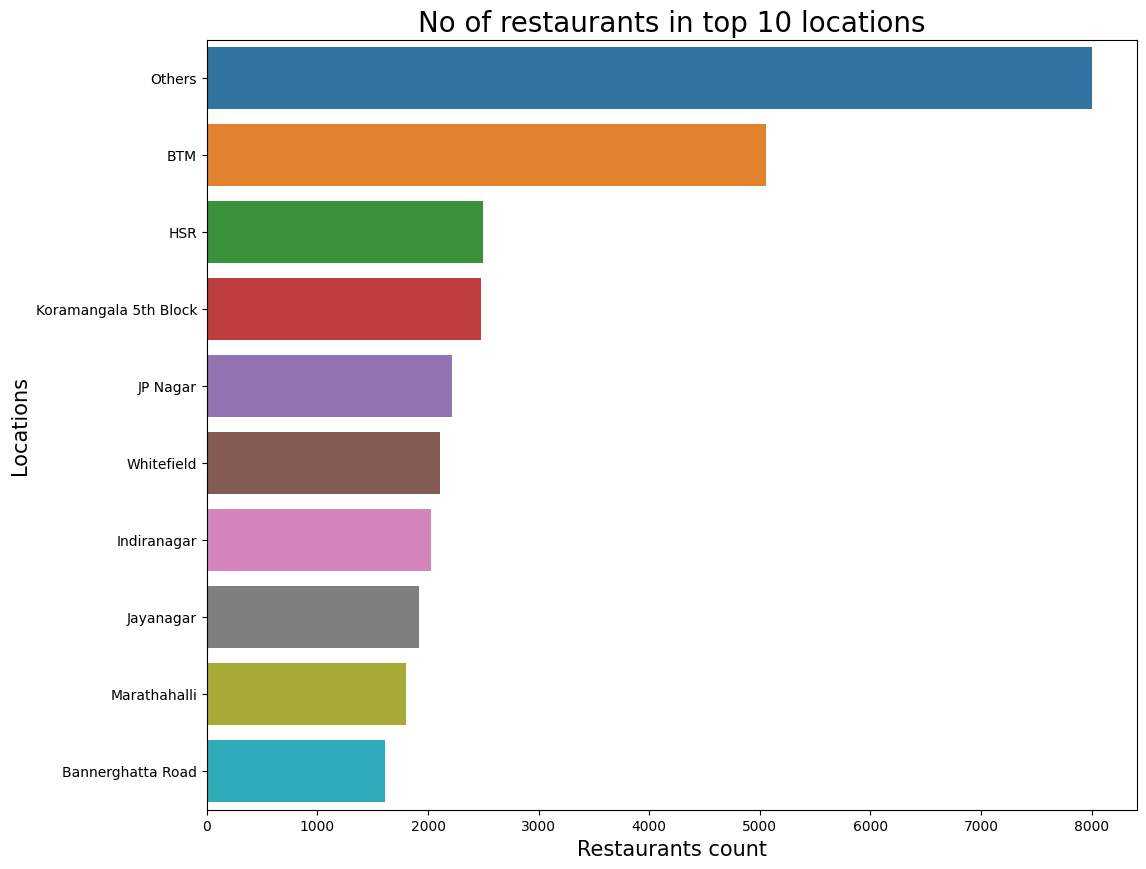

In [41]:
plt.figure(figsize=(12,10))
sns.barplot(x = 'count',y= 'location',data=locations)
plt.title("No of restaurants in top 10 locations",fontsize = 20)
plt.xlabel("Restaurants count",fontsize=15)
plt.ylabel("Locations",fontsize = 15)

# Q2) What are the most common types of restaurants?

In [42]:
df['rest_type'].value_counts()

rest_type
Quick Bites                    19010
Casual Dining                  10253
Cafe                            3682
Delivery                        2574
Dessert Parlor                  2242
Takeaway, Delivery              2008
Others                          1485
Bakery                          1140
Casual Dining, Bar              1130
Beverage Shop                    863
Bar                              686
Food Court                       616
Sweet Shop                       468
Bar, Casual Dining               411
Lounge                           395
Pub                              355
Fine Dining                      345
Casual Dining, Cafe              311
Beverage Shop, Quick Bites       293
Bakery, Quick Bites              286
Mess                             264
Pub, Casual Dining               255
Sweet Shop, Quick Bites          178
Kiosk                            176
Dessert Parlor, Cafe             175
Cafe, Casual Dining              173
Cafe, Bakery                

In [43]:
rest_type_count = df['rest_type'].value_counts().head(10).reset_index()
rest_type_count

,rest_type,count
0,Quick Bites,19010
1,Casual Dining,10253
2,Cafe,3682
3,Delivery,2574
4,Dessert Parlor,2242
5,"Takeaway, Delivery",2008
6,Others,1485
7,Bakery,1140
8,"Casual Dining, Bar",1130
9,Beverage Shop,863


Text(0, 0.5, 'Restaurant type')

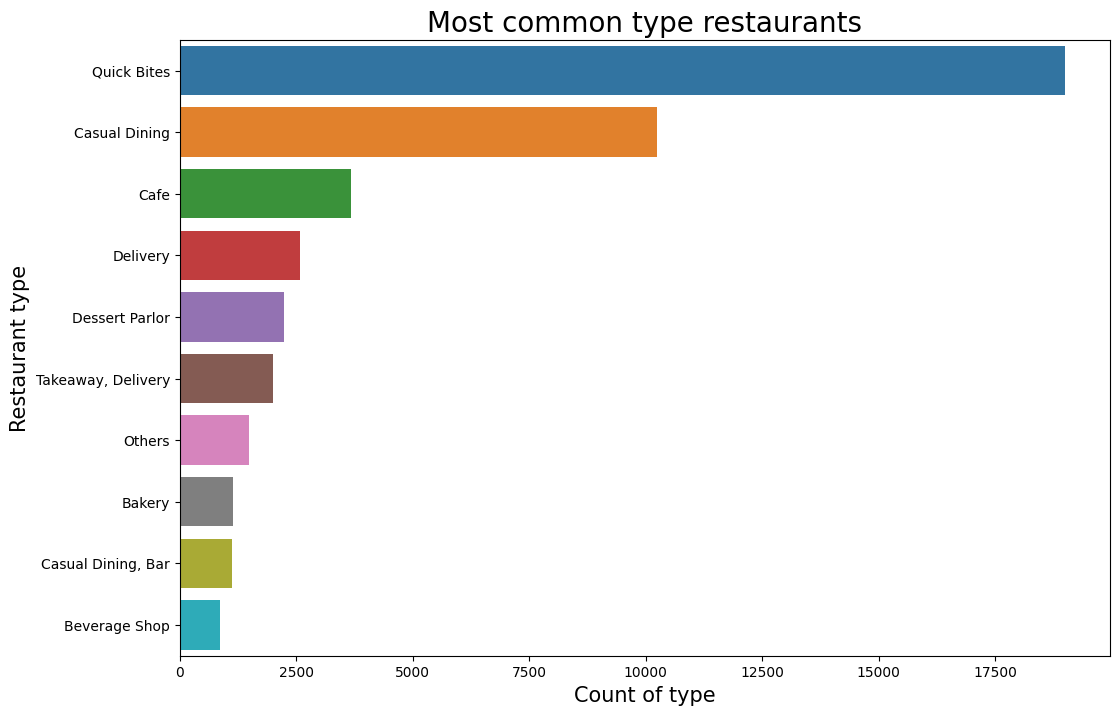

In [44]:
plt.figure(figsize=(12,8))
sns.barplot(x='count',y = 'rest_type' , data = rest_type_count)
plt.title("Most common type restaurants",fontsize = 20)
plt.xlabel("Count of type",fontsize=15)
plt.ylabel("Restaurant type",fontsize = 15)

# Q3) What is the rate of online ordering availible?

([<matplotlib.patches.Wedge at 0x7c99b0b4c610>,
 [Text(-1.0927116553129623, -0.12641692269314925, 'Yes'),
  Text(1.0927116553129623, 0.1264169226931496, 'No')])

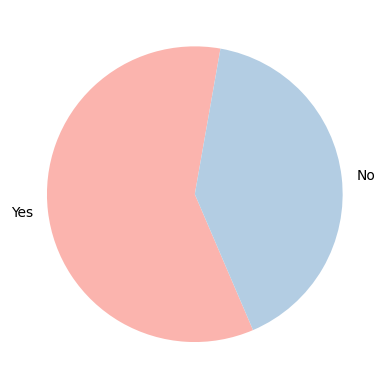

In [45]:
online_order_availability = df['online_order'].value_counts()
plt.pie(online_order_availability,labels = online_order_availability.index,colors = sns.color_palette('Pastel1'),startangle = 80)

In [46]:
df['online_order'].value_counts()

online_order
Yes    30228
No     20814
Name: count, dtype: int64

<Axes: xlabel='online_order', ylabel='count'>

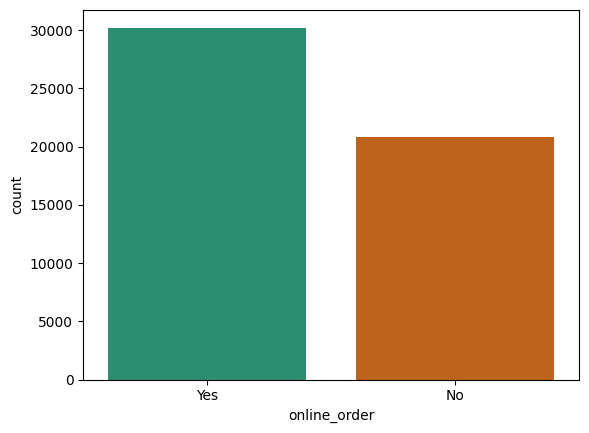

In [47]:
sns.countplot(x = 'online_order',data = df, palette='Dark2')

# Q4) What are the most common types of restaurant services?

In [48]:
common_type = df['Type'].value_counts().head(5)
common_type

Type
Delivery              25579
Dine-out              17562
Desserts               3559
Cafes                  1703
Drinks & nightlife     1084
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x7c99b0a0c610>,
 [Text(-1.0521537600529072, 0.32089323022857585, 'Delivery'),
  Text(0.8421123709443794, -0.7077052738975712, 'Dine-out'),
  Text(0.8810303721547241, 0.6586239316490924, 'Desserts'),
  Text(0.6163860568385656, 0.911080802637727, 'Cafes'),
  Text(0.4464080053542973, 1.0053456583462217, 'Drinks & nightlife')])

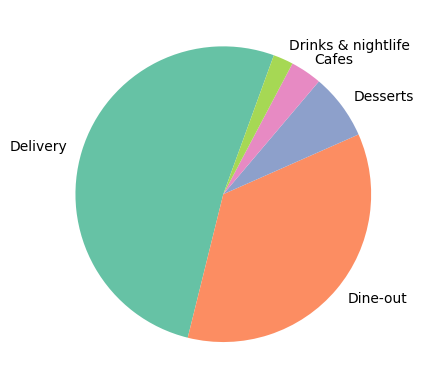

In [49]:
plt.pie(common_type,labels = common_type.index,startangle = 70,colors =sns.color_palette('Set2'))

# Q5) What is the availabilty of online and offline orders in different locations?

In [50]:
online_order_locations = pd.crosstab(df['location'],df['online_order'])
online_order_locations

online_order,No,Yes
location,,
BTM,1763,3293
Banashankari,397,505
Banaswadi,302,338
Bannerghatta Road,685,924
Basavanagudi,243,441
Bellandur,517,751
Brigade Road,552,658
Brookefield,239,417
Church Street,226,340


<Axes: title={'center': 'Online order availability'}, xlabel='location'>

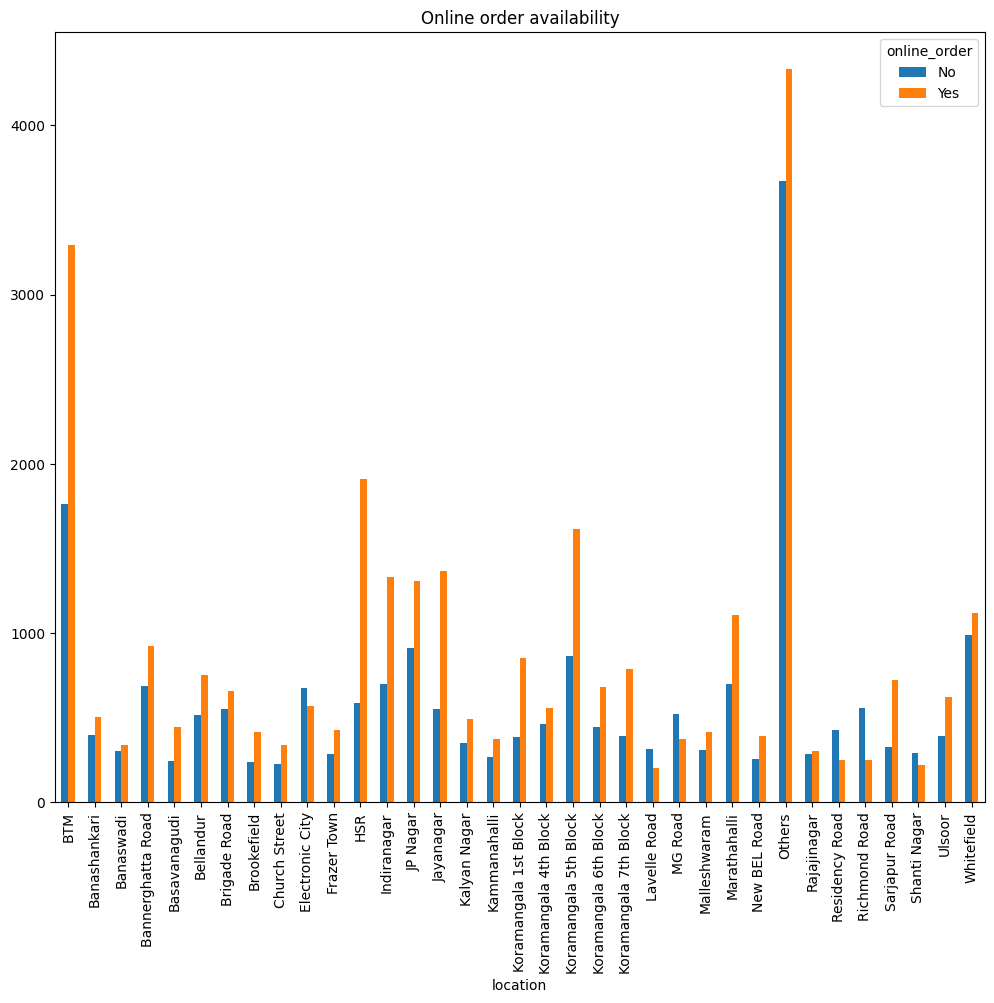

In [51]:
online_order_locations.plot(kind = 'bar',figsize = (12,10),title = 'Online order availability',)

# Q6: What is the availabilty of Booking tables in different locations?

In [52]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,2platescost,Type
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,Others,800.0,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet


<Axes: title={'center': 'Book table availability in different locations'}, xlabel='location'>

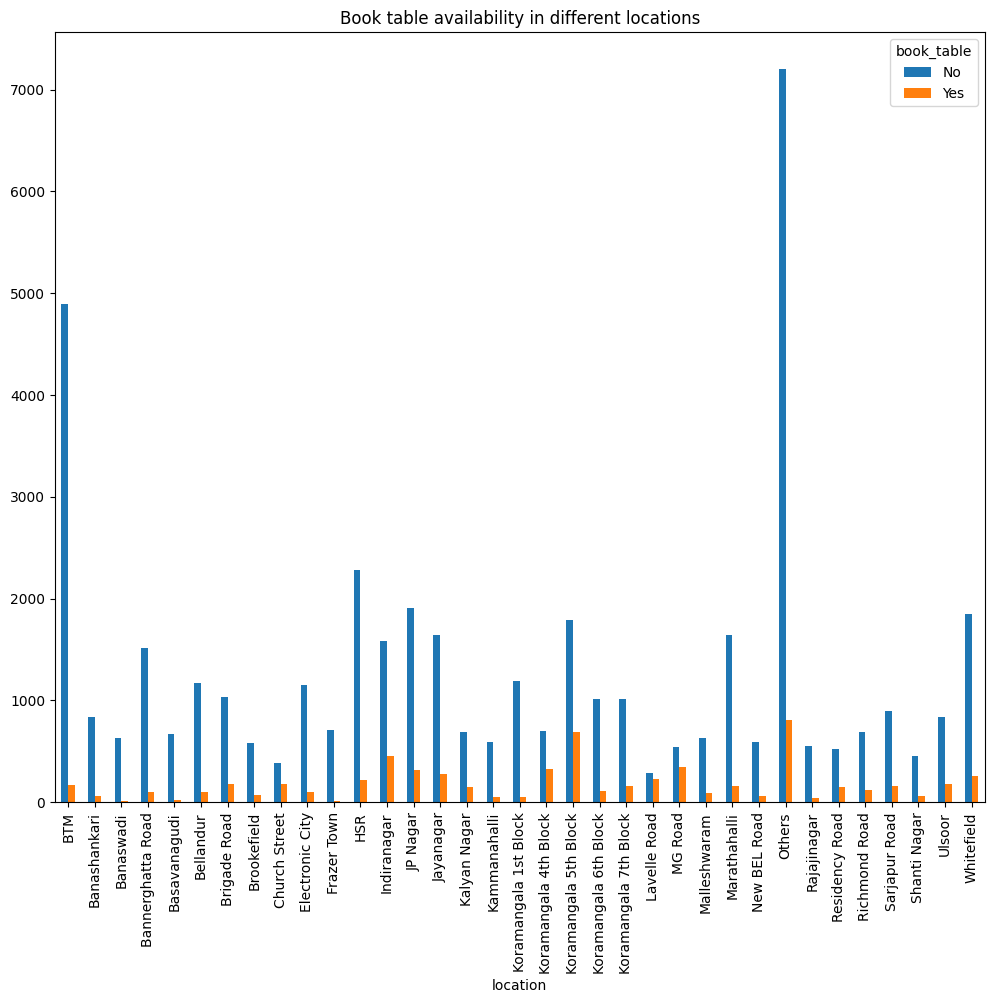

In [53]:
table_book_avail = pd.crosstab(df['location'],df['book_table'])
table_book_avail.plot(kind = 'bar',figsize = (12,10),title = 'Book table availability in different locations')

# Q7: Which type of restaurants has highest rate?

Text(0, 0.5, 'Rating out of 5')

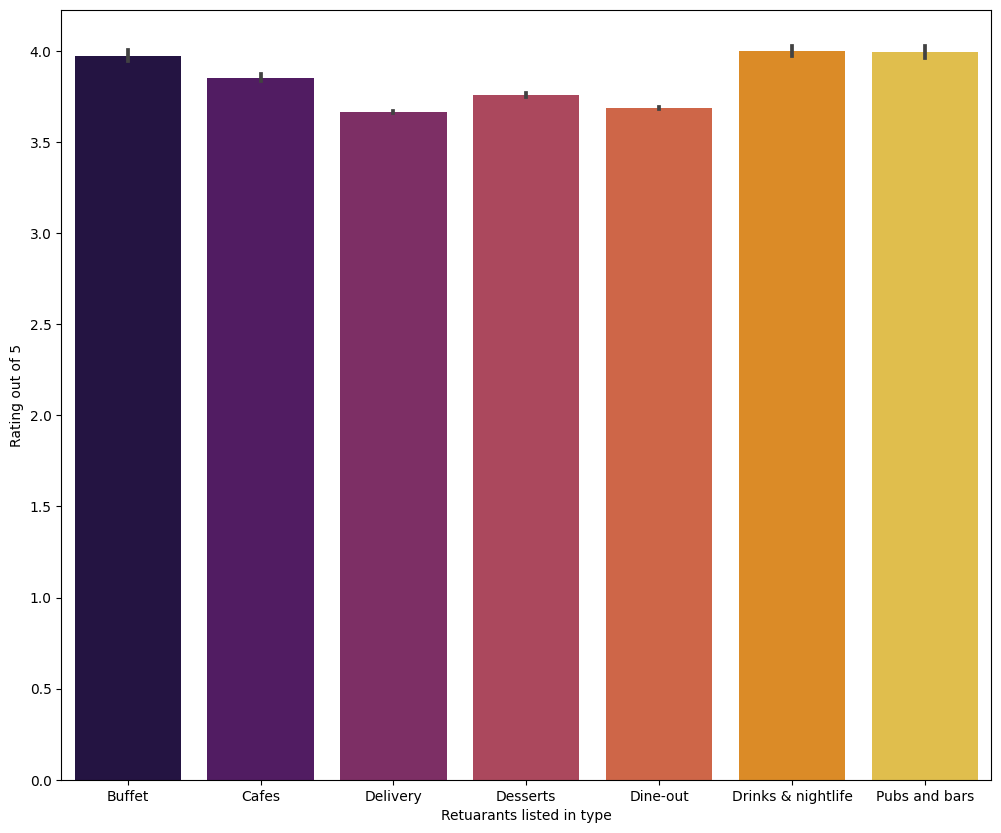

In [54]:
plt.figure(figsize = (12,10))
sns.barplot(x = 'Type', y = 'rate',data = df,palette = 'inferno')
plt.xlabel("Retuarants listed in type")
plt.ylabel("Rating out of 5")

# Q8: What is distribuation of place types in different locations?

In [55]:
df2 = df['location'].value_counts().head(10)
df2

location
Others                   8007
BTM                      5056
HSR                      2494
Koramangala 5th Block    2479
JP Nagar                 2218
Whitefield               2105
Indiranagar              2026
Jayanagar                1916
Marathahalli             1805
Bannerghatta Road        1609
Name: count, dtype: int64

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34]),
 [Text(0, 0, 'Banashankari'),
  Text(1, 0, 'Basavanagudi'),
  Text(2, 0, 'Others'),
  Text(3, 0, 'Jayanagar'),
  Text(4, 0, 'JP Nagar'),
  Text(5, 0, 'Bannerghatta Road'),
  Text(6, 0, 'BTM'),
  Text(7, 0, 'Electronic City'),
  Text(8, 0, 'HSR'),
  Text(9, 0, 'Marathahalli'),
  Text(10, 0, 'Shanti Nagar'),
  Text(11, 0, 'Koramangala 5th Block'),
  Text(12, 0, 'Richmond Road'),
  Text(13, 0, 'Koramangala 7th Block'),
  Text(14, 0, 'Koramangala 4th Block'),
  Text(15, 0, 'Bellandur'),
  Text(16, 0, 'Sarjapur Road'),
  Text(17, 0, 'Whitefield'),
  Text(18, 0, 'Indiranagar'),
  Text(19, 0, 'Koramangala 1st Block'),
  Text(20, 0, 'Frazer Town'),
  Text(21, 0, 'MG Road'),
  Text(22, 0, 'Brigade Road'),
  Text(23, 0, 'Lavelle Road'),
  Text(24, 0, 'Church Street'),
  Text(25, 0, 'Ulsoor'),
  Text(26, 0, 'Residency Road'),
  Text(

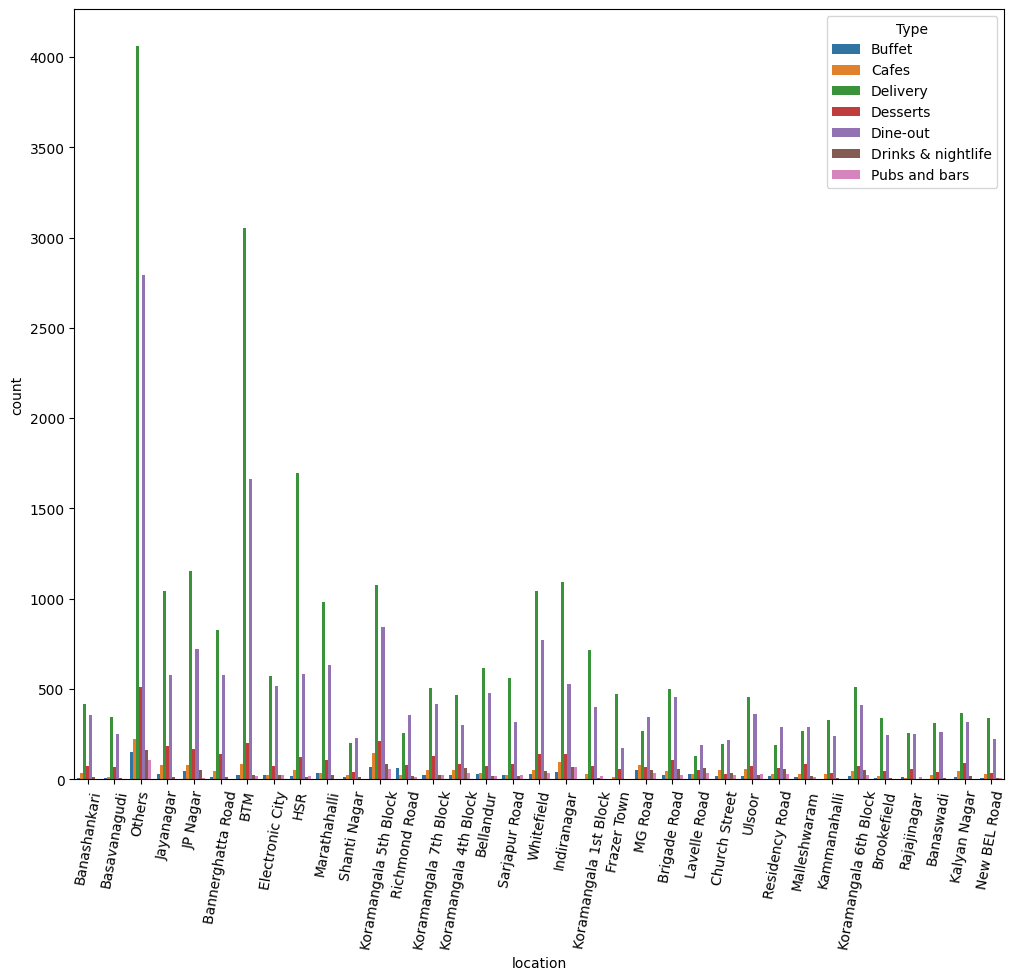

In [56]:
plt.figure(figsize=(12,10))
sns.countplot(x = 'location',data =df,hue = 'Type')
plt.xlabel("location")
plt.xticks(rotation = 80)

In [57]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,2platescost,Type
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,Others,800.0,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet


In [58]:
location_type_count = df.groupby(['location','Type']).size().reset_index(name = 'count')
top_10 = df['location'].value_counts().head(10).index
location_type_count  = location_type_count[location_type_count['location'].isin(top_10)]
location_type_count

pivot_df = location_type_count.pivot(index = 'location',columns = 'Type',values = 'count').fillna(0)
pivot_df

Type,Buffet,Cafes,Delivery,Desserts,Dine-out,Drinks & nightlife,Pubs and bars
location,,,,,,,
BTM,21.0,83.0,3053.0,198.0,1660.0,22.0,19.0
Bannerghatta Road,9.0,46.0,828.0,137.0,578.0,9.0,2.0
HSR,19.0,49.0,1694.0,120.0,580.0,14.0,18.0
Indiranagar,38.0,97.0,1091.0,140.0,529.0,65.0,66.0
JP Nagar,45.0,76.0,1151.0,166.0,722.0,51.0,7.0
Jayanagar,27.0,77.0,1043.0,182.0,575.0,12.0,0.0
Koramangala 5th Block,65.0,146.0,1075.0,209.0,842.0,84.0,58.0
Marathahalli,34.0,32.0,980.0,105.0,630.0,22.0,2.0
Others,150.0,225.0,4062.0,512.0,2792.0,162.0,104.0


<Axes: xlabel='location'>

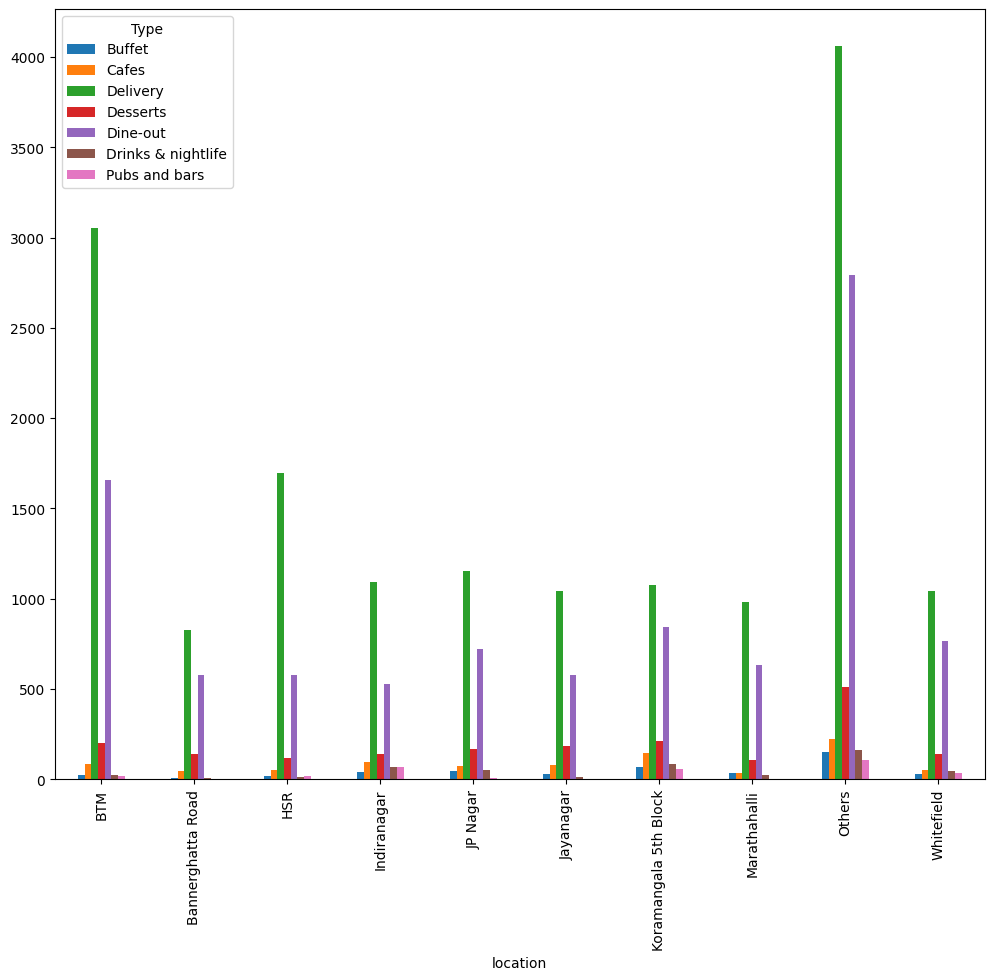

In [59]:
pivot_df.plot(kind = 'bar',figsize = (12,10))

# Q9 Is there any correlation between these online order, table booking and restaurant ratings?

In [60]:
df1 = df.dropna(subset = ['rate'] )
df1.groupby(['online_order','book_table'])['rate'].describe()

count      mean       std  min  25%       50%  \
online_order book_table                                                    
No           No          18181.0  3.604215  0.345562  1.8  3.4  3.700142   
             Yes          2633.0  4.144403  0.312036  2.5  3.9  4.200000   
Yes          No          26445.0  3.663424  0.378730  2.1  3.5  3.700142   
             Yes          3783.0  4.125934  0.301152  2.2  4.0  4.100000   

                              75%  max  
online_order book_table                 
No           No          3.700142  4.9  
             Yes         4.400000  4.9  
Yes          No          3.900000  4.9  
             Yes         4.300000  4.9